# Rock-Paper-Scissors Image Classification
### Transfer Learning + Fine-Tuning with MobileNetV2

This notebook is structured as a **two-phase training recipe** that is the standard playbook
for image classification when you have a small dataset (a few thousand images):

1. **Phase 1 — Transfer Learning.** Freeze a pretrained backbone (MobileNetV2 trained on ImageNet)
   and train *only* a new classification head. The backbone acts as a fixed feature extractor.
2. **Phase 2 — Fine-Tuning.** Unfreeze the top layers of the backbone and continue training with a
   *much smaller* learning rate so the pretrained features adapt to our domain without being destroyed.

#### What this notebook fixes vs. earlier attempts
- **Generalization gap.** Earlier runs showed ~95% validation accuracy but only ~87% test accuracy.
  That ~8–10 point gap is a classic **distribution shift** symptom: train/val are split from the
  *same* folder (so they share lighting, hands, backgrounds), while the test folder is recorded
  separately. We attack this with **stronger augmentation**, **dropout**, and **better callbacks**.
- **Data hygiene.** We keep a clean **train / validation / test** split where the test set is held
  out *until the very last cell*. We never pick a model based on test performance.
- **Diagnostics.** We add training curves, a confusion matrix, and per-class metrics so you can
  *see* where the model fails — not just read a single number.

## 1. Imports

We import Keras (high-level API), TensorFlow (for `tf.data` pipelines), NumPy, Matplotlib, and a
couple of scikit-learn metrics for the confusion matrix and classification report.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers
import tensorflow as tf

from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

2026-05-07 01:41:53.337286: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.16.2
Keras: 3.14.0


## 2. Configuration

All hyperparameters live in one place so you can tweak them without hunting through the notebook.

> **Why `IMAGE_SIZE = (160, 160)`?** MobileNetV2 ships with weights for several input sizes
> (96, 128, 160, 192, 224). Larger inputs give the model more spatial detail but cost more
> compute. 160×160 is a sweet spot for small datasets like RPS — enough resolution to see fingers
> clearly, fast enough to train on a CPU.

In [2]:
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 42

DATA_DIR = 'rps_dataset/train'   # used for train + validation (split 80/20)
TEST_DIR = 'rps_dataset/test'    # held-out test set, never seen during training

# Reproducibility: seeds Python random, NumPy, and TF/Keras in one call.
keras.utils.set_random_seed(SEED)

## 3. Loading the data

We use `keras.utils.image_dataset_from_directory`, which expects this folder structure:

```
rps_dataset/
├── train/
│   ├── rock/      *.png
│   ├── paper/     *.png
│   └── scissors/  *.png
└── test/
    ├── rock/      *.png
    ├── paper/     *.png
    └── scissors/  *.png
```

#### The 3-way split, and why it matters
- **Train (80% of `train/`)** — what the model learns from.
- **Validation (20% of `train/`)** — used during training for early stopping, LR scheduling, and
  picking the best checkpoint.
- **Test (`test/`)** — touched **once** at the end of each phase. If you peek at it during
  development, it stops being a test set and becomes a second validation set.

...

> **Critical detail:** for the train/val split to be deterministic and non-overlapping, both
> `image_dataset_from_directory` calls must use the **same `seed`** and **same `validation_split`**.

In [3]:
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = 'training',
    seed = SEED,
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = 'validation',
    seed = SEED,            # MUST match the training call
)

# Held-out test set — keep `shuffle=False` so predictions line up with labels for the
# confusion matrix later.
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False,
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Found 2520 files belonging to 3 classes.
Using 2016 files for training.
Found 2520 files belonging to 3 classes.
Using 504 files for validation.
Found 372 files belonging to 3 classes.
Classes (3): ['paper', 'rock', 'scissors']


## 4. Sanity-check: look at the data

**Always plot a batch before you train.** This catches issues that no accuracy number ever will:
mislabeled folders, all-black images, wrong color channels, totally different distributions
between train and test, etc.

2026-05-07 01:46:09.818323: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


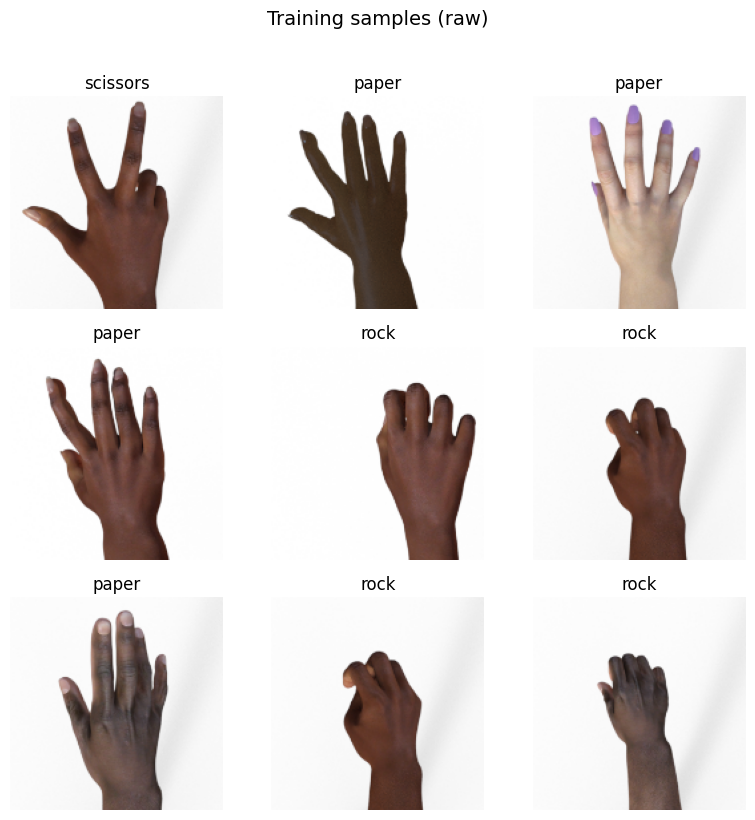

2026-05-07 01:46:10.699434: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


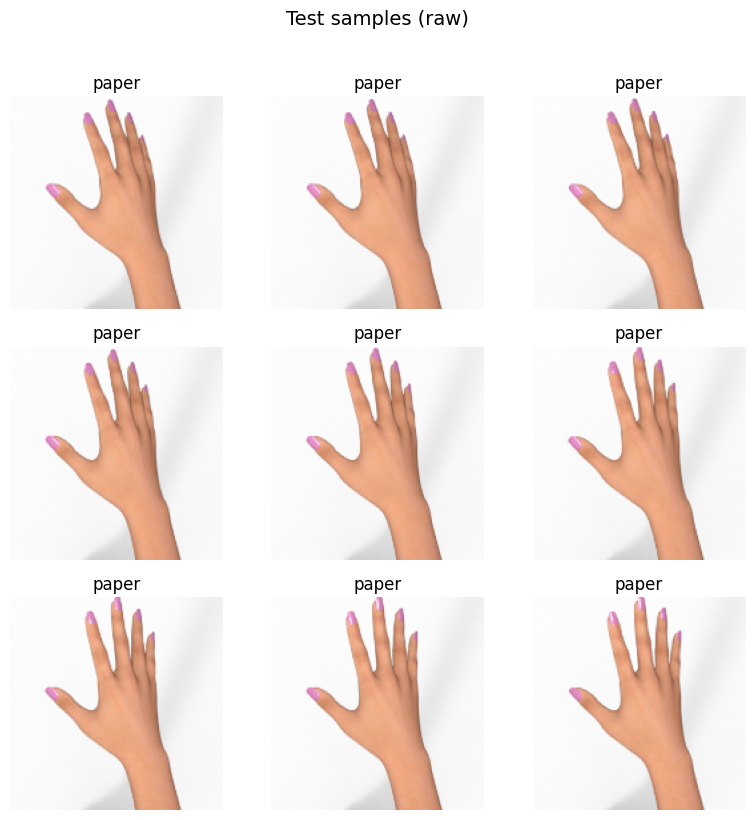

In [4]:
def show_batch(dataset, class_names, title, n=9):
    plt.figure(figsize=(8, 8))
    for images, labels in dataset.take(1):
        for i in range(min(n, images.shape[0])):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype('uint8'))
            plt.title(class_names[int(labels[i])])
            plt.axis('off')
    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

show_batch(train_ds, CLASS_NAMES, 'Training samples (raw)')
show_batch(test_ds,  CLASS_NAMES, 'Test samples (raw)')

**Take a moment to compare the two figures above.** If the test images look noticeably
different from training images (different background color, lighting, hand position, camera
angle), that visual difference is exactly what's causing your test accuracy to lag behind
validation accuracy. Strong augmentation in the next section is the main lever to fix this.

## 5. `tf.data` performance pipeline

Three small tricks that make training noticeably faster on CPU and don't hurt accuracy:

| Method        | What it does                                                                  |
|---------------|-------------------------------------------------------------------------------|
| `.cache()`    | After the 1st epoch, the dataset lives in RAM — no more re-decoding from disk.|
| `.shuffle()`  | Random order each epoch (training only — never shuffle val/test).             |
| `.prefetch()` | Overlaps data prep with model compute on the GPU/CPU.                         |

...

> Order matters: `cache → shuffle → prefetch`. Caching *before* shuffling means we shuffle the
> *cached* tensors (cheap), not re-read the files (expensive).

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

## 6. Data augmentation — the main fix for the val-vs-test gap

This is **the most important section** of this notebook. The earlier attempts used only
`RandomFlip + RandomRotation + RandomZoom`. That's enough to prevent overfitting to the *training*
set, but it doesn't help when the test set has different **lighting**, **contrast**, or **framing**
than the training set — and that's exactly what's happening here.

We add four more transformations:
- **`RandomBrightness`** — simulates variable lighting conditions.
- **`RandomContrast`** — simulates different camera sensors / exposure settings.
- **`RandomTranslation`** — hand isn't always perfectly centered in the test photos.
- A larger **`RandomZoom`** range — handles cameras held at different distances.

Augmentation is wrapped in a `Sequential` block and lives **inside the model**. That way:
- It runs on the GPU as part of the forward pass during training.
- It's automatically a no-op at inference time (Keras turns these layers off when `training=False`).

In [6]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.2),         # ±20% of 2π  ≈ ±72°
        layers.RandomZoom(0.3),             # was 0.2 — bumped up
        layers.RandomTranslation(0.1, 0.1), # NEW: shift up to 10% in each axis
        layers.RandomBrightness(0.2),       # NEW: vary brightness
        layers.RandomContrast(0.2),         # NEW: vary contrast
    ],
    name='data_augmentation',
)

### Visualize the augmentation
Plot the *same* image augmented 9 different ways. You should see meaningful variation —
different angles, different brightnesses, different framings. If every tile looks identical,
augmentation isn't actually firing.

2026-05-07 01:50:15.291898: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


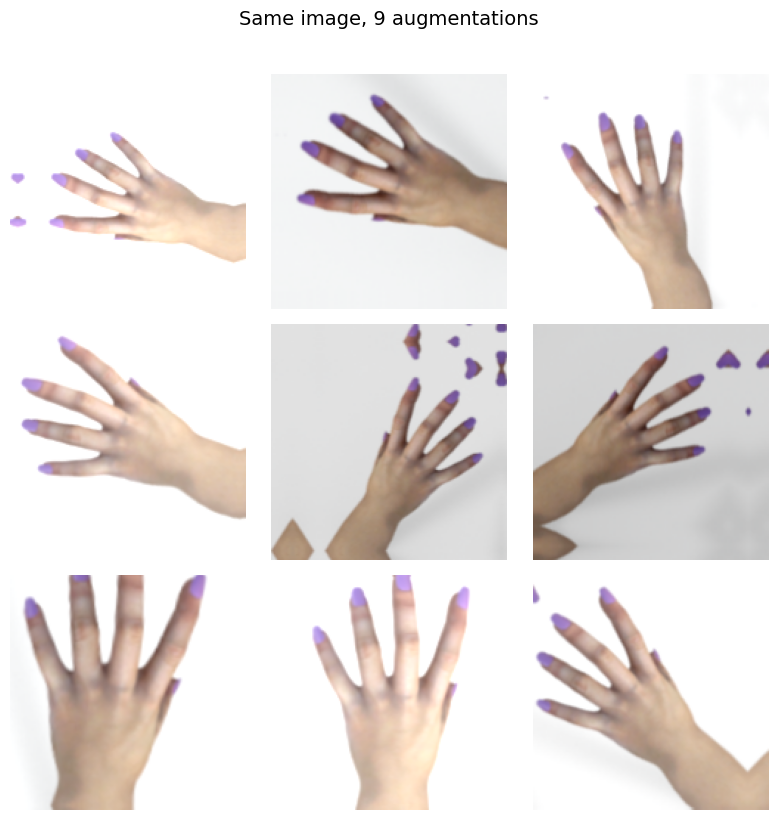

In [7]:
plt.figure(figsize=(8, 8))
for images, _ in train_ds.take(1):
    first = images[0]
    for i in range(9):
        augmented = data_augmentation(tf.expand_dims(first, 0), training=True)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(augmented[0], tf.uint8))
        plt.axis('off')
plt.suptitle('Same image, 9 augmentations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Phase 1 — Transfer learning (frozen backbone)

We load MobileNetV2 with ImageNet weights and **drop its classification head** (`include_top=False`).
With `base_model.trainable = False`, the ~2.2M backbone parameters are frozen — only the new head
on top will train.

...

> **Why freeze first?** A randomly initialized head produces large, noisy gradients. If the
> backbone were trainable from the start, those gradients would flow back and corrupt the
> carefully-pretrained features. Train the head first, *then* unfreeze.

In [8]:
base_model = MobileNetV2(
    weights = 'imagenet',
    input_shape = IMAGE_SIZE + (3,),
    include_top = False,
)
base_model.trainable = False

print(f"Backbone params: {base_model.count_params():,}")

Backbone params: 2,257,984


### Build the full model

The forward pass is:

```
Input (160×160×3, uint8)
  → data_augmentation        (random flips/rotations/etc., training-only)
  → preprocess_input         (scales pixels to [-1, 1], MobileNetV2's expected range)
  → base_model               (frozen feature extractor → 5×5×1280 feature map)
  → GlobalAveragePooling2D   (5×5×1280 → 1280-d vector)
  → Dropout(0.2)             (regularization — NEW)
  → Dense(3, softmax)        (classifier head)
```

The `Dropout` layer is new — it randomly zeros 20% of the pooled features during training, which
forces the classifier to not rely on any single feature too heavily. Cheap and effective.

In [9]:
inputs = keras.Input(shape=IMAGE_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)        
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)                
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Compile

- **Optimizer:** Adam with `lr=1e-4`. Standard, robust default for transfer learning.
- **Loss:** `sparse_categorical_crossentropy` because our labels are integers (0/1/2), not one-hot.
- **Metrics:** plain `accuracy` is fine — RPS is balanced.

In [10]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'],
)

### Callbacks (Phase 1)

We use three callbacks together — they each do one job:

| Callback             | Job                                                                        |
|----------------------|----------------------------------------------------------------------------|
| `EarlyStopping`      | Stop when val loss hasn't improved in 3 epochs; restore the best weights.  |
| `ReduceLROnPlateau`  | If val loss plateaus, cut the learning rate in half — a small free win.    |
| `ModelCheckpoint`    | Save the best model to disk so you can come back to it later.              |

In [11]:
os.makedirs('checkpoints', exist_ok=True)

phase1_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 3,
        restore_best_weights = True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 2,
        min_lr = 1e-7,
        verbose = 1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath = 'checkpoints/phase1_best.keras',
        monitor = 'val_loss',
        save_best_only = True,
        verbose = 0,
    ),
]

### Train Phase 1

In [13]:
EPOCHS_PHASE1 = 10

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = EPOCHS_PHASE1,
    callbacks = phase1_callbacks, 
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 559ms/step - accuracy: 0.4246 - loss: 1.1796 - val_accuracy: 0.4841 - val_loss: 0.9311 - learning_rate: 1.0000e-04
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 533ms/step - accuracy: 0.6225 - loss: 0.8313 - val_accuracy: 0.7063 - val_loss: 0.6751 - learning_rate: 1.0000e-04
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 543ms/step - accuracy: 0.7336 - loss: 0.6504 - val_accuracy: 0.8175 - val_loss: 0.5284 - learning_rate: 1.0000e-04
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 556ms/step - accuracy: 0.8075 - loss: 0.5194 - val_accuracy: 0.8532 - val_loss: 0.4455 - learning_rate: 1.0000e-04
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 532ms/step - accuracy: 0.8512 - loss: 0.4476 - val_accuracy: 0.8849 - val_loss: 0.3820 - learning_rate: 1.0000e-04
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 527ms/step - accuracy: 0.8869 - loss: 0.3661 - val_accuracy: 0.9067 - val_loss: 0.3341 - learning_rate: 1.0000e-04
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 551ms/step - acc

### Evaluate Phase 1 on the test set

This is our **first** look at the test set. Whatever number we get here is an honest estimate of
how the *frozen-backbone* model generalizes.

In [14]:
phase1_test_loss, phase1_test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nPhase 1 — test accuracy: {phase1_test_acc:.4f}  |  test loss: {phase1_test_loss:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 432ms/step - accuracy: 0.9435 - loss: 0.2408

Phase 1 — test accuracy: 0.9435  |  test loss: 0.2408


## 8. Phase 2 — Fine-tuning

Now we unfreeze the **top** of the backbone and continue training. The intuition:

- Early conv layers learn very generic features (edges, textures, colors). They don't need to
  change for our RPS task.
- Late conv layers learn task-specific features (object parts, complex shapes). These benefit
  from being adapted to *our* hand images.

MobileNetV2 has 154 layers. We freeze the first 100 and let the remaining ~54 train.

In [16]:
base_model.trainable = True

FINE_TUNE_AT = 100
print(f"Total layers in base model: {len(base_model.layers)}")
print(f"Freezing layers 0 - {FINE_TUNE_AT - 1}, training layers {FINE_TUNE_AT} - {len(base_model.layers) - 1}")

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

Total layers in base model: 154
Freezing layers 0 - 99, training layers 100 - 153


### Re-compile with a much smaller learning rate

> **You MUST re-compile after changing `trainable`** — otherwise Keras keeps using the old
> trainable-variable list and your unfrozen layers won't actually update.

The learning rate drops by **10×** (`1e-4 → 1e-5`). With a higher LR, the unfrozen layers would
take huge steps and destroy the pretrained features. Small steps = gentle adaptation.

In [17]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),   # 10× smaller than Phase 1
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'],
)

### Callbacks (Phase 2)

Same three callbacks. We swap the checkpoint filename so we don't overwrite Phase 1.

In [18]:
phase2_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 3,
        restore_best_weights = True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 2,
        min_lr = 1e-8,
        verbose = 1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath = 'checkpoints/phase2_best.keras',
        monitor = 'val_loss',
        save_best_only = True,
        verbose = 0,
    ),
]

### Train Phase 2

We continue from the last Phase 1 epoch using `initial_epoch` so the epoch counter and the
training-curve plots line up.

In [19]:
EPOCHS_PHASE2 = 10
total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2

history_fine = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = total_epochs,
    initial_epoch = history.epoch[-1] + 1,
    callbacks = phase2_callbacks,
)

Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 840ms/step - accuracy: 0.8264 - loss: 0.4515 - val_accuracy: 0.9306 - val_loss: 0.2019 - learning_rate: 1.0000e-05
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 742ms/step - accuracy: 0.9330 - loss: 0.2436 - val_accuracy: 0.9325 - val_loss: 0.1978 - learning_rate: 1.0000e-05
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 745ms/step - accuracy: 0.9549 - loss: 0.1516 - val_accuracy: 0.9425 - val_loss: 0.1704 - learning_rate: 1.0000e-05
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9707 - loss: 0.1099 - val_accuracy: 0.9484 - val_loss: 0.1520 - learning_rate: 1.0000e-05
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 756s 12s/step - accuracy: 0.9752 - loss: 0.0927 - val_accuracy: 0.9544 - val_loss: 0.1175 - learning_rate: 1.0000e-05
Epoch 16/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 720ms/step - accuracy: 0.9782 - loss: 0.0707 - val_accuracy: 0.9643 - val_loss: 0.0990 - learning_rate: 1.0000e-05
Epoch 17/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 714ms/step - 

## 9. Training curves

Stitch Phase 1 and Phase 2 histories together and plot them. The vertical dashed line marks
where fine-tuning began — you should see a noticeable jump in performance there.

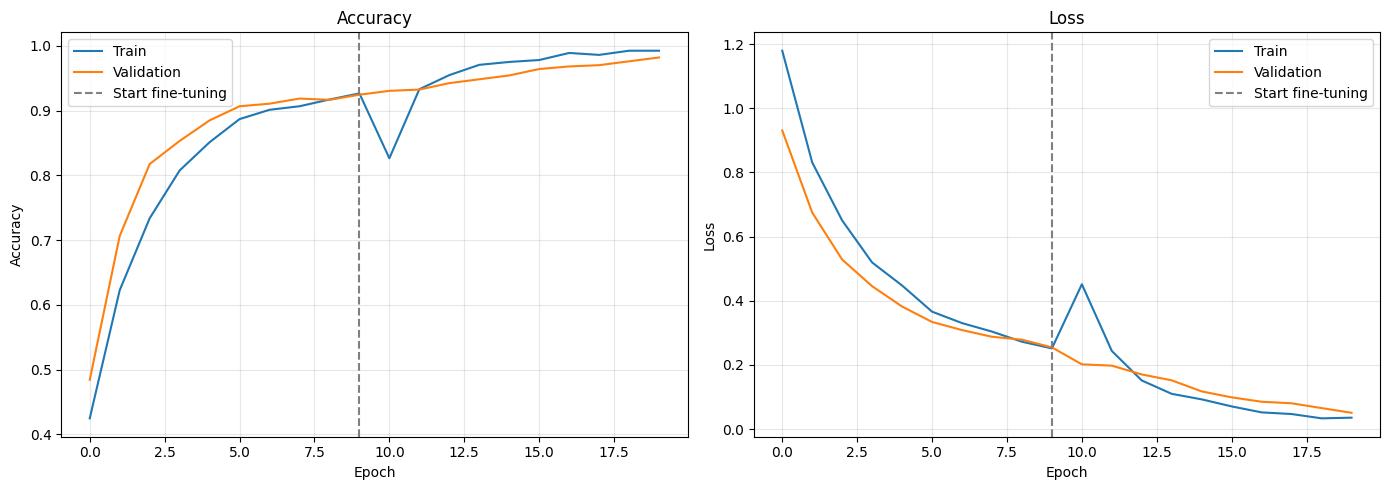

In [20]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc, label='Train')
ax1.plot(val_acc, label='Validation')
ax1.axvline(EPOCHS_PHASE1 - 1, ls='--', color='gray', label='Start fine-tuning')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(loss, label='Train')
ax2.plot(val_loss, label='Validation')
ax2.axvline(EPOCHS_PHASE1 - 1, ls='--', color='gray', label='Start fine-tuning')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Final evaluation on the held-out test set

In [21]:
final_test_loss, final_test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nFinal — test accuracy: {final_test_acc:.4f}  |  test loss: {final_test_loss:.4f}")
print(f"Phase 1 test accuracy:  {phase1_test_acc:.4f}")
print(f"Improvement from FT:    {(final_test_acc - phase1_test_acc) * 100:+.2f} pp")

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 397ms/step - accuracy: 0.9086 - loss: 0.1886

Final — test accuracy: 0.9086  |  test loss: 0.1886
Phase 1 test accuracy:  0.9435
Improvement from FT:    -3.49 pp


## 11. Where does the model fail? Confusion matrix + per-class metrics

A single accuracy number tells you almost nothing about *what* the model got wrong. The confusion
matrix shows which classes get mixed up, and the classification report breaks down precision /
recall / F1 per class.

For RPS specifically, "rock" and "paper" can be confused when the camera angle hides the fingers,
and "scissors" is usually the most distinctive shape.

2026-05-07 02:43:53.616751: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


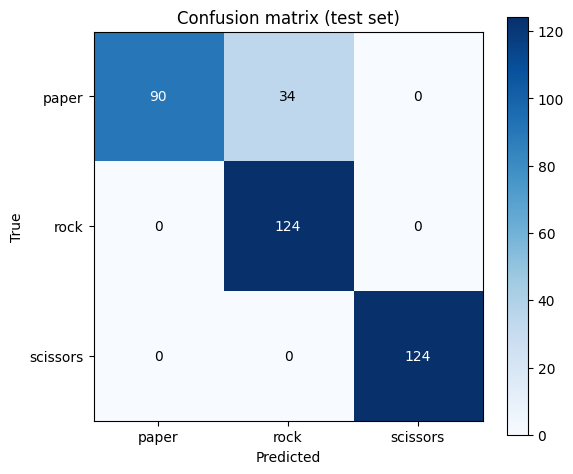


Classification report:
              precision    recall  f1-score   support

       paper     1.0000    0.7258    0.8411       124
        rock     0.7848    1.0000    0.8794       124
    scissors     1.0000    1.0000    1.0000       124

    accuracy                         0.9086       372
   macro avg     0.9283    0.9086    0.9069       372
weighted avg     0.9283    0.9086    0.9069       372



In [22]:
# Collect predictions and labels over the entire test set
y_true, y_pred = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix (test set)')

# Annotate each cell with the count
thresh = cm.max() / 2
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

### Inspect a few misclassified examples
Looking at *where* the model is wrong is often more informative than looking at *how often*.

Misclassified: 34 / 372 (9.14%)


2026-05-07 02:44:49.239558: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


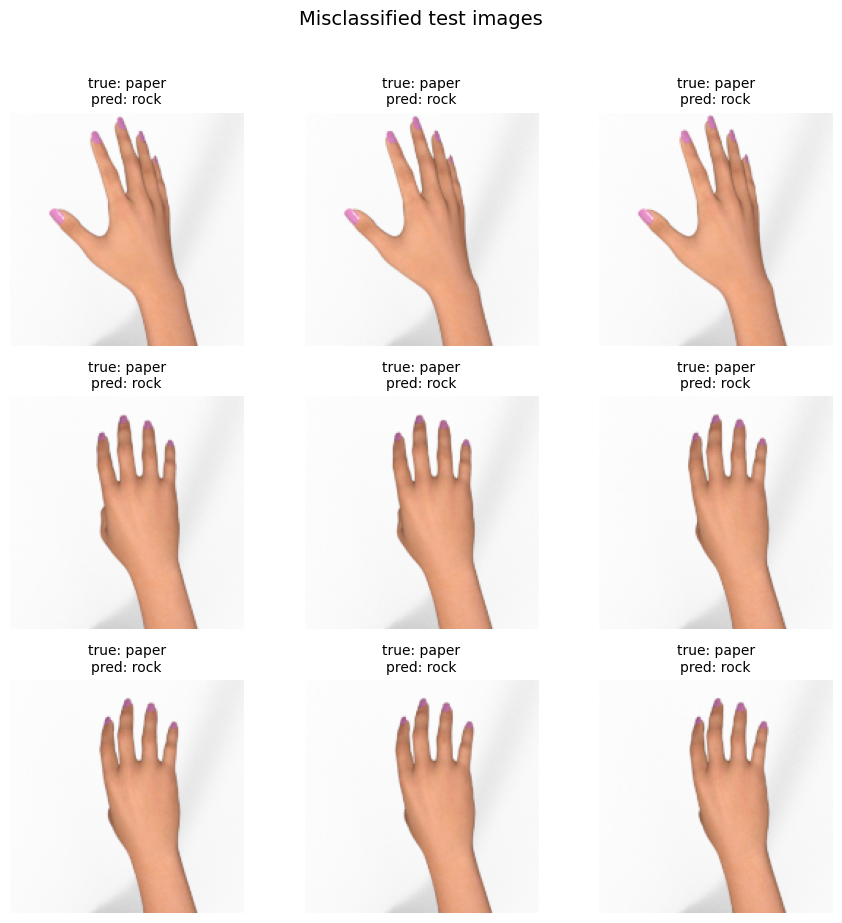

In [23]:
mis_idx = np.where(y_true != y_pred)[0]
print(f"Misclassified: {len(mis_idx)} / {len(y_true)} ({len(mis_idx) / len(y_true):.2%})")

if len(mis_idx) > 0:
    # Re-collect images aligned to the (un-shuffled) test set
    all_images = []
    for images, _ in test_ds:
        all_images.append(images.numpy())
    all_images = np.concatenate(all_images, axis=0)

    n_show = min(9, len(mis_idx))
    plt.figure(figsize=(9, 9))
    for i, idx in enumerate(mis_idx[:n_show]):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(all_images[idx].astype('uint8'))
        plt.title(f"true: {CLASS_NAMES[y_true[idx]]}\npred: {CLASS_NAMES[y_pred[idx]]}",
                  fontsize=10)
        plt.axis('off')
    plt.suptitle('Misclassified test images', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 12. Save the final model

Use the native Keras format (`.keras`). It's a single file containing architecture, weights, and
optimizer state — everything needed to load and continue training or to deploy.

In [ ]:
# model.save('rps_mobilenetv2_finetuned.keras')
# print("Saved -> rps_mobilenetv2_finetuned.keras")

## 13. What to try next

If your test accuracy is still not where you want it, here's the rough order of things to try
(cheapest → most expensive):

1. **More augmentation strength.** Bump `RandomBrightness` to 0.3, add `RandomTranslation(0.15, 0.15)`.
2. **More fine-tuning epochs.** With a low LR, more epochs rarely hurts — let `EarlyStopping` decide.
3. **Larger input size.** Re-load MobileNetV2 with `IMAGE_SIZE = (224, 224)`. More detail, slower training.
4. **More dropout.** Try `Dropout(0.3)` or `Dropout(0.4)` if you see train-acc ≫ val-acc.
5. **Unfreeze more layers.** Drop `FINE_TUNE_AT` from 100 → 80. More capacity to adapt.
6. **Bigger backbone.** Swap `MobileNetV2` for `EfficientNetB0` or `ResNet50V2`. Same recipe, more params.
7. **Collect more test-like data.** Ultimately, the cleanest fix for a train↔test distribution gap
   is a few hundred more training images that *look like* the test set.

Always change **one thing at a time** and re-evaluate. If you change three things at once and
accuracy improves, you don't know which change actually helped.